In [1]:
# imports
import data_loader as dl
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Import the dataset:

In [ ]:
%pip install kagglehub
import kagglehub

# Download latest version (NOTE: Filesize is about 509MB, files are .png)
# path = kagglehub.dataset_download("koryakinp/fingers")

# locate the dataset files
path = "/mnt/cs/cs153/data/fingers/versions/2"

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.


/Users/irandolph/Desktop/HMC/Year 3/Semester 2/CS 153 - Computer Vision/project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/irandolph/.cache/kagglehub/datasets/koryakinp/fingers/versions/2


Now that dataset imported, let's look at it:

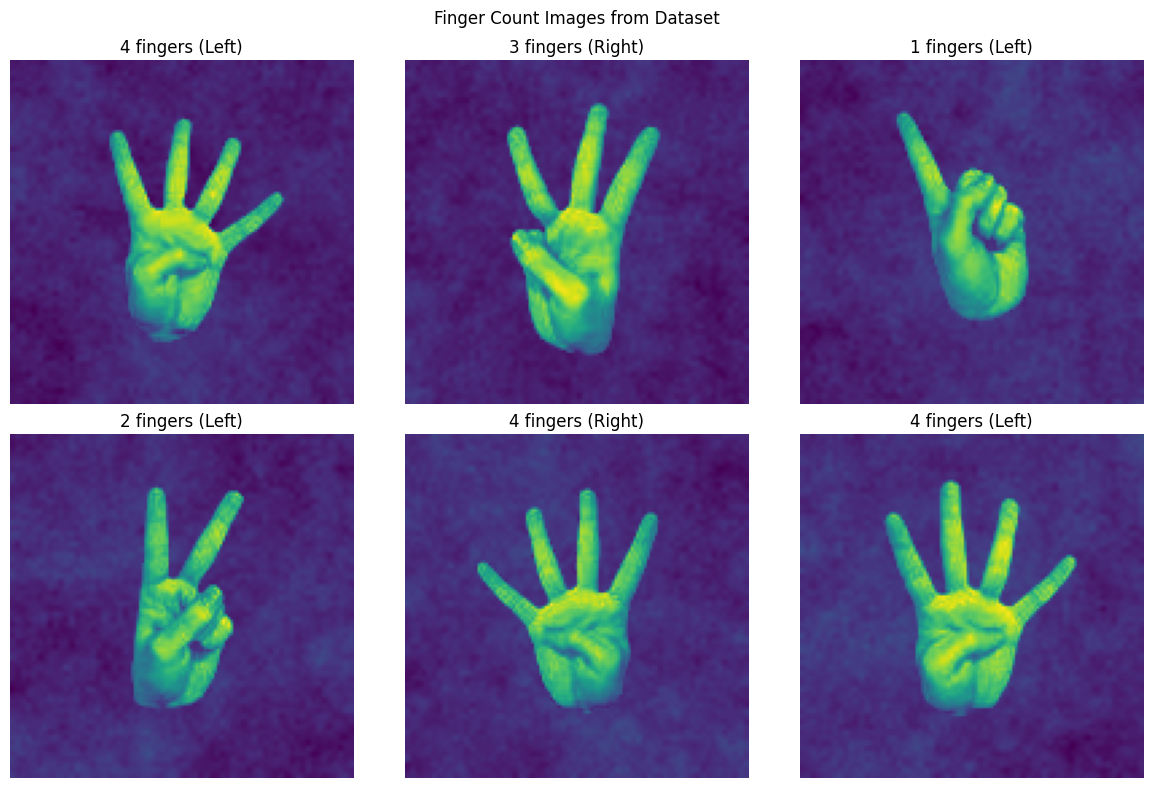

In [3]:
import os
from PIL import Image

import matplotlib.pyplot as plt

path_in = path + "/fingers/test"

# Get list of image files from the dataset path
image_files = [f for f in os.listdir(path_in) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:6]

# Display images in a grid
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, img_file in enumerate(image_files):
    img_path = os.path.join(path_in, img_file)
    img = Image.open(img_path)
    axes[idx].imshow(img)
    
    # Extract number and side from filename
    parts = img_file.split('_')
    if len(parts) > 1:
        num_side = parts[1].split('.')[0]  # e.g., '4L'
        num = num_side[:-1]
        side = num_side[-1]
        if side == 'L':
            side_str = 'Left'
        elif side == 'R':
            side_str = 'Right'
        else:
            side_str = side
        title = f"{num} fingers ({side_str})"
    else:
        title = img_file
    
    axes[idx].set_title(title)
    axes[idx].axis('off')

# Add a title to the figure
fig.suptitle("Finger Count Images from Dataset")

plt.tight_layout()
plt.show()

Now let's use the dataloader to prepare the dataset for training.

In [4]:
train_path = path + "/fingers/train"
test_path = path + "/fingers/test"

In [5]:
train_data = dl.get_data_loader(train_path)

Now let's get our pretrained model and begin transfer learning!

In [ ]:
from torchvision import models
import torch
import torch.nn as nn
import torch.optim as optim

import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 6)

# -- MAYBE LATER: MobileNetV2, supposed to be better for real-time applications -- #
# model = models.mobilenet_v2(pretrained=True)
# model.classifier[1] = nn.Linear(model.last_channel, 5)

# Now begin transfer learning!

# Assuming train_data is a DataLoader from dl.load_data
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Move model to device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training loop (simple example for transfer learning)
num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_data:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_data):.4f}')

/Users/irandolph/Desktop/HMC/Year 3/Semester 2/CS 153 - Computer Vision/project/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/irandolph/Desktop/HMC/Year 3/Semester 2/CS 153 - Computer Vision/project/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


KeyboardInterrupt: 